# 04 - Unifying Data Sources

This notebook addresses the challenge of combining `annotations.csv` and `candidates.csv` into a unified dataset.

## Problem

The coordinates in `annotations.csv` are not perfectly aligned with those in `candidates.csv`. For example:
- **annotations.csv**: `(-128.70, -175.32, -298.39)`
- **candidates.csv**: `(-128.94, -175.04, -297.87)`

Both represent the same nodule (~5mm diameter), but with ~0.5mm differences in coordinates.

## Solution

We create a unified `CandidateInfoTuple` that:
1. Matches candidates to annotations based on coordinate proximity (within radius)
2. Incorporates diameter information from annotations
3. Returns sorted data for representative sampling

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add src to path for importing our module
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data" / "luna"
print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")

Project root: /Users/carlos/Library/CloudStorage/Dropbox/Sigmoidal/Cursos/Deep Learning para Visão Computacional/lung-cancer-detection
Data dir: /Users/carlos/Library/CloudStorage/Dropbox/Sigmoidal/Cursos/Deep Learning para Visão Computacional/lung-cancer-detection/data/luna


## 1. Analyzing Coordinate Misalignment

First, let's quantify the coordinate differences between the two files.

In [2]:
# Load both CSV files
annotations_df = pd.read_csv(DATA_DIR / "annotations.csv")
candidates_df = pd.read_csv(DATA_DIR / "candidates.csv")

print(f"Annotations: {len(annotations_df)} entries")
print(f"Candidates: {len(candidates_df)} entries")
print(f"\nPositive candidates (class=1): {candidates_df['class'].sum()}")

Annotations: 1186 entries
Candidates: 551065 entries

Positive candidates (class=1): 1351


In [3]:
# For positive candidates, try to find matching annotations
# and calculate the distance between coordinates

positive_candidates = candidates_df[candidates_df['class'] == 1].copy()

distances = []
matched_diameters = []

for _, cand in positive_candidates.iterrows():
    # Get annotations for this series
    ann_for_series = annotations_df[annotations_df['seriesuid'] == cand['seriesuid']]
    
    if len(ann_for_series) == 0:
        continue
    
    # Find closest annotation
    min_dist = float('inf')
    matched_diam = 0
    
    for _, ann in ann_for_series.iterrows():
        dist = np.sqrt(
            (cand['coordX'] - ann['coordX'])**2 +
            (cand['coordY'] - ann['coordY'])**2 +
            (cand['coordZ'] - ann['coordZ'])**2
        )
        if dist < min_dist:
            min_dist = dist
            matched_diam = ann['diameter_mm']
    
    distances.append(min_dist)
    matched_diameters.append(matched_diam)

distances = np.array(distances)
matched_diameters = np.array(matched_diameters)

print(f"Analyzed {len(distances)} positive candidates")

Analyzed 1351 positive candidates


In [4]:
# Statistics of coordinate differences
print("Distance between candidate and nearest annotation (mm):")
print(f"  Min:    {distances.min():.3f}")
print(f"  Max:    {distances.max():.3f}")
print(f"  Mean:   {distances.mean():.3f}")
print(f"  Median: {np.median(distances):.3f}")
print(f"  Std:    {distances.std():.3f}")

Distance between candidate and nearest annotation (mm):
  Min:    0.032
  Max:    15.919
  Mean:   2.431
  Median: 1.253
  Std:    2.887


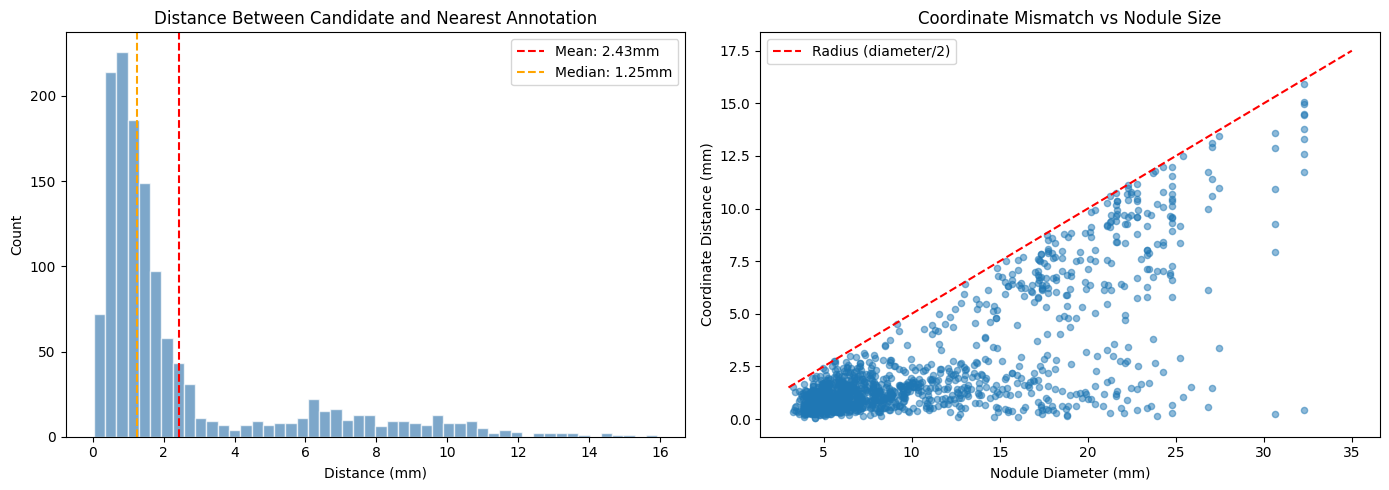

In [5]:
# Visualize the distribution of distances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of distances
axes[0].hist(distances, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(distances.mean(), color='red', linestyle='--', label=f'Mean: {distances.mean():.2f}mm')
axes[0].axvline(np.median(distances), color='orange', linestyle='--', label=f'Median: {np.median(distances):.2f}mm')
axes[0].set_xlabel('Distance (mm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distance Between Candidate and Nearest Annotation')
axes[0].legend()

# Distance vs Diameter scatter
axes[1].scatter(matched_diameters, distances, alpha=0.5, s=20)
axes[1].set_xlabel('Nodule Diameter (mm)')
axes[1].set_ylabel('Coordinate Distance (mm)')
axes[1].set_title('Coordinate Mismatch vs Nodule Size')

# Add reference line for radius
x_range = np.linspace(3, 35, 100)
axes[1].plot(x_range, x_range/2, 'r--', label='Radius (diameter/2)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Check how many candidates would match using radius threshold
within_radius = (distances <= matched_diameters / 2).sum()
print(f"Candidates within radius threshold: {within_radius}/{len(distances)} ({100*within_radius/len(distances):.1f}%)")

# Also check with slightly larger thresholds
for factor in [0.6, 0.7, 0.8, 1.0]:
    within = (distances <= matched_diameters * factor).sum()
    print(f"  Within diameter*{factor}: {within}/{len(distances)} ({100*within/len(distances):.1f}%)")

Candidates within radius threshold: 1351/1351 (100.0%)
  Within diameter*0.6: 1351/1351 (100.0%)
  Within diameter*0.7: 1351/1351 (100.0%)
  Within diameter*0.8: 1351/1351 (100.0%)
  Within diameter*1.0: 1351/1351 (100.0%)


## 2. Using the Unified Data Module

Now let's use our `CandidateInfoTuple` from `src/data/candidates.py`.

In [7]:
from data.candidates import CandidateInfoTuple, get_candidate_info_list

# Load unified candidate list (cached)
%time candidate_list = get_candidate_info_list(DATA_DIR)

print(f"\nTotal candidates loaded: {len(candidate_list):,}")

CPU times: user 2.98 s, sys: 74.4 ms, total: 3.06 s
Wall time: 3.06 s

Total candidates loaded: 551,065


In [8]:
# Second call should be instant due to caching
%time candidate_list_cached = get_candidate_info_list(DATA_DIR)
print(f"Same object: {candidate_list is candidate_list_cached}")

CPU times: user 6 μs, sys: 0 ns, total: 6 μs
Wall time: 10 μs
Same object: True


In [9]:
# Examine the structure
print("CandidateInfoTuple fields:", CandidateInfoTuple._fields)
print("\nFirst 5 candidates (sorted - nodules first, larger diameter first):")
for c in candidate_list[:5]:
    print(f"  is_nodule={c.is_nodule}, diameter={c.diameter_mm:.2f}mm, uid={c.series_uid[:20]}...")

CandidateInfoTuple fields: ('is_nodule', 'diameter_mm', 'series_uid', 'center_xyz')

First 5 candidates (sorted - nodules first, larger diameter first):
  is_nodule=True, diameter=32.27mm, uid=1.3.6.1.4.1.14519.5....
  is_nodule=True, diameter=32.27mm, uid=1.3.6.1.4.1.14519.5....
  is_nodule=True, diameter=32.27mm, uid=1.3.6.1.4.1.14519.5....
  is_nodule=True, diameter=32.27mm, uid=1.3.6.1.4.1.14519.5....
  is_nodule=True, diameter=32.27mm, uid=1.3.6.1.4.1.14519.5....


In [10]:
# Statistics
nodules = [c for c in candidate_list if c.is_nodule]
nodules_with_diameter = [c for c in nodules if c.diameter_mm > 0]

print(f"Total candidates: {len(candidate_list):,}")
print(f"Nodules (is_nodule=True): {len(nodules):,}")
print(f"Nodules with diameter info: {len(nodules_with_diameter):,}")
print(f"Non-nodules: {len(candidate_list) - len(nodules):,}")

Total candidates: 551,065
Nodules (is_nodule=True): 1,351
Nodules with diameter info: 1,351
Non-nodules: 549,714


## 3. Diameter Distribution

Let's visualize the diameter distribution of matched nodules.

In [11]:
# Extract diameters from nodules with diameter info
diameters = [c.diameter_mm for c in nodules_with_diameter]

print(f"Diameter statistics (mm):")
print(f"  Count:  {len(diameters)}")
print(f"  Min:    {min(diameters):.2f}")
print(f"  Max:    {max(diameters):.2f}")
print(f"  Mean:   {np.mean(diameters):.2f}")
print(f"  Median: {np.median(diameters):.2f}")

Diameter statistics (mm):
  Count:  1351
  Min:    3.25
  Max:    32.27
  Mean:   10.55
  Median: 7.63


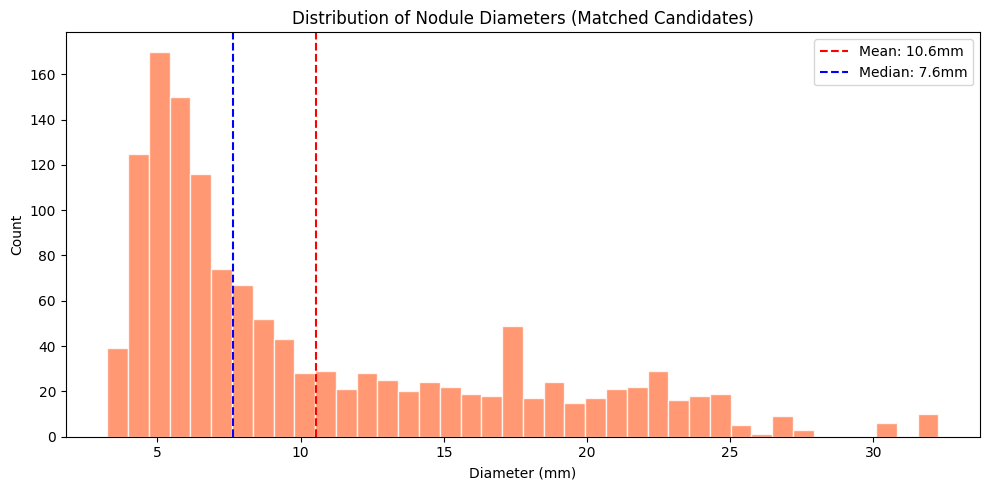

In [12]:
# Visualize diameter distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(diameters, bins=40, color='coral', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(diameters), color='red', linestyle='--', label=f'Mean: {np.mean(diameters):.1f}mm')
ax.axvline(np.median(diameters), color='blue', linestyle='--', label=f'Median: {np.median(diameters):.1f}mm')

ax.set_xlabel('Diameter (mm)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Nodule Diameters (Matched Candidates)')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Sorted Data for Representative Sampling

The data is sorted by:
1. `is_nodule` (True first)
2. `diameter_mm` (larger first)
3. `series_uid` (alphabetically)

This ordering ensures that when we extract every N-th element for validation, we get a representative distribution of nodule sizes.

In [13]:
# Show how the sorting works
print("First 10 candidates (largest nodules):")
for i, c in enumerate(candidate_list[:10]):
    print(f"  {i+1}. is_nodule={c.is_nodule}, diameter={c.diameter_mm:.2f}mm")

print("\n...")
print(f"\nLast 10 candidates (non-nodules):")
for i, c in enumerate(candidate_list[-10:]):
    print(f"  {len(candidate_list)-9+i}. is_nodule={c.is_nodule}, diameter={c.diameter_mm:.2f}mm")

First 10 candidates (largest nodules):
  1. is_nodule=True, diameter=32.27mm
  2. is_nodule=True, diameter=32.27mm
  3. is_nodule=True, diameter=32.27mm
  4. is_nodule=True, diameter=32.27mm
  5. is_nodule=True, diameter=32.27mm
  6. is_nodule=True, diameter=32.27mm
  7. is_nodule=True, diameter=32.27mm
  8. is_nodule=True, diameter=32.27mm
  9. is_nodule=True, diameter=32.27mm
  10. is_nodule=True, diameter=32.27mm

...

Last 10 candidates (non-nodules):
  551056. is_nodule=False, diameter=0.00mm
  551057. is_nodule=False, diameter=0.00mm
  551058. is_nodule=False, diameter=0.00mm
  551059. is_nodule=False, diameter=0.00mm
  551060. is_nodule=False, diameter=0.00mm
  551061. is_nodule=False, diameter=0.00mm
  551062. is_nodule=False, diameter=0.00mm
  551063. is_nodule=False, diameter=0.00mm
  551064. is_nodule=False, diameter=0.00mm
  551065. is_nodule=False, diameter=0.00mm


In [14]:
# Demonstrate representative sampling (every N-th element)
N = 10  # Take every 10th element

nodule_subset = nodules_with_diameter[::N]
subset_diameters = [c.diameter_mm for c in nodule_subset]

print(f"Full dataset: {len(nodules_with_diameter)} nodules with diameter")
print(f"Subset (every {N}th): {len(nodule_subset)} nodules")
print(f"\nFull dataset - Mean diameter: {np.mean(diameters):.2f}mm, Std: {np.std(diameters):.2f}mm")
print(f"Subset       - Mean diameter: {np.mean(subset_diameters):.2f}mm, Std: {np.std(subset_diameters):.2f}mm")

Full dataset: 1351 nodules with diameter
Subset (every 10th): 136 nodules

Full dataset - Mean diameter: 10.55mm, Std: 6.64mm
Subset       - Mean diameter: 10.59mm, Std: 6.72mm


## Summary

This notebook:
1. **Analyzed** coordinate misalignment between `annotations.csv` and `candidates.csv`
2. **Demonstrated** the unified `CandidateInfoTuple` structure from `src/data/candidates.py`
3. **Showed** the diameter distribution of matched nodules
4. **Illustrated** how sorted data enables representative sampling

**Next:** Use this unified data to create PyTorch DataLoaders for training.